In [1]:
import polars as pl

In [2]:
df = (
    pl.read_csv(
        "/mnt/yokoyamalab-nas/gldv2-full/csv/interior-exterior/train_index_clean_tags_exterior_only_geo.csv"
    )
    .with_columns(pl.col("category").str.split(",").alias("category"))
    .with_columns(
        pl.col("category").list.eval(
            pl.element().filter(~pl.element().is_in(["other"]))
        )
    )
    .filter(pl.col("category").list.len() == 1)
    .with_columns(pl.col("category").list.first())
)

In [3]:
df = df.filter(pl.col("country_code").is_in(["US", "DE", "GB", "FR", "JP"]))
len(df)

684853

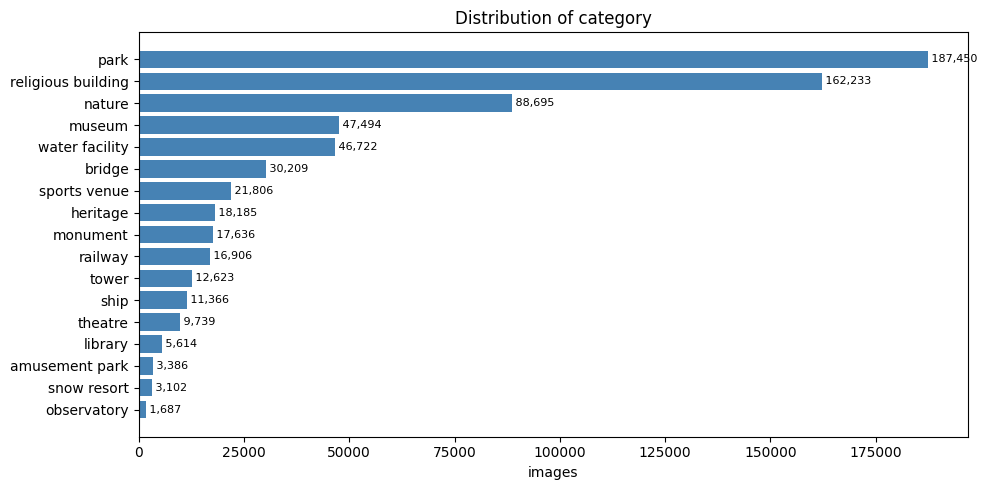

In [4]:
import matplotlib.pyplot as plt

# 1. Distribution of the category column
cat_dist = (
    df.group_by("category")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .with_columns((pl.col("n") / pl.col("n").sum()).alias("pct"))
)

# with pl.Config(tbl_rows=-1):
#     print(cat_dist)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cat_dist["category"], cat_dist["n"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("images")
ax.set_title("Distribution of category")
for y, v in enumerate(cat_dist["n"]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

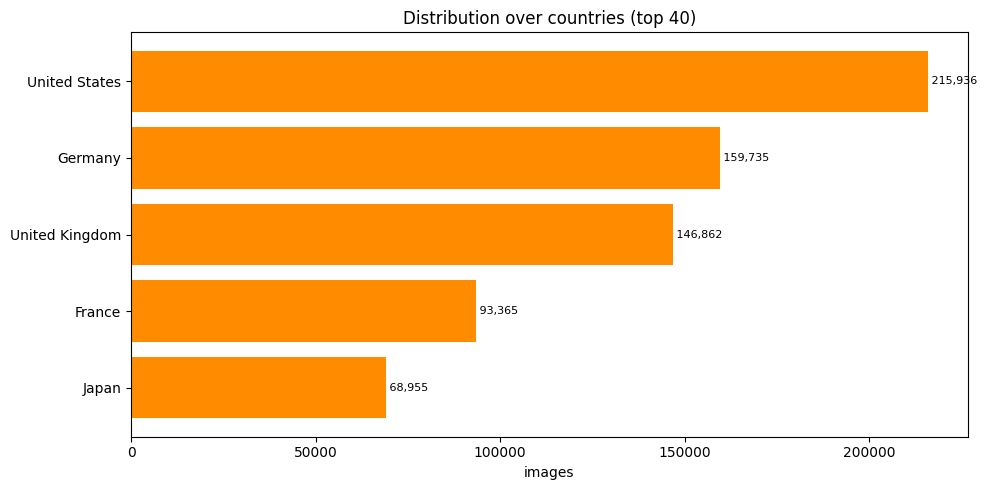

In [5]:
# 2. Distribution of data over countries
country_dist = (
    df.group_by("country")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .with_columns(
        (pl.col("n") / pl.col("n").sum()).alias("pct"),
        (pl.col("n").cum_sum() / pl.col("n").sum()).alias("cum_pct"),
    )
)

# with pl.Config(tbl_rows=-1):
#     print(country_dist)

topk = country_dist.head(40)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(topk["country"], topk["n"], color="darkorange")
ax.invert_yaxis()
ax.set_xlabel("images")
ax.set_title("Distribution over countries (top 40)")
for y, v in enumerate(topk["n"]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# 3. Drop categories with fewer than 10K images
MIN_IMAGES = 10_000

keep_categories = (
    df.group_by("category")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") >= MIN_IMAGES)
    .get_column("category")
    .to_list()
)

df = df.filter(pl.col("category").is_in(keep_categories))
print(f"kept {len(keep_categories)} categories, {len(df):,} rows")

kept 12 categories, 661,325 rows


In [8]:
import numpy as np

# --- Train/val/test split, grouped by wikimedia_url, stratified over (country, category) ---
SEED = 42
F_VAL = 0.15
F_TEST = 0.15
SMALL = 5  # cells with fewer URLs than this go entirely to train

# 1. Assign each wikimedia_url to its dominant (country, category) cell
url_cell = (
    df.group_by(["wikimedia_url", "country", "category"])
    .agg(pl.len().alias("n_images"))
    .sort(["wikimedia_url", "n_images"], descending=[False, True])
    .group_by("wikimedia_url", maintain_order=True)
    .first()
    .select(["wikimedia_url", "country", "category", "n_images"])
)

# 2. Count URLs (W) per (country, category) cell
cells = url_cell.group_by(["country", "category"]).agg(pl.len().alias("W"))

# 3. Rank URLs randomly within each cell, carve off test/val quotas
rng = np.random.default_rng(SEED)
url_df = (
    url_cell.join(cells, on=["country", "category"], how="left")
    .with_columns(u=pl.Series("u", rng.random(url_cell.height)))
    .with_columns(rk=pl.col("u").rank("ordinal").over(["country", "category"]) - 1)
    .with_columns(
        n_test=pl.when(pl.col("W") >= SMALL)
        .then(pl.max_horizontal(pl.lit(1), (F_TEST * pl.col("W")).round()))
        .otherwise(0)
        .cast(pl.Int64),
        n_val=pl.when(pl.col("W") >= SMALL)
        .then(pl.max_horizontal(pl.lit(1), (F_VAL * pl.col("W")).round()))
        .otherwise(0)
        .cast(pl.Int64),
    )
    .with_columns(
        split=pl.when(pl.col("W") < SMALL)
        .then(pl.lit("train"))
        .when(pl.col("rk") < pl.col("n_test"))
        .then(pl.lit("test"))
        .when(pl.col("rk") < pl.col("n_test") + pl.col("n_val"))
        .then(pl.lit("val"))
        .otherwise(pl.lit("train"))
    )
)

# 4. Propagate split back to image level
df = df.join(url_df.select(["wikimedia_url", "split"]), on="wikimedia_url", how="left")

# --- sanity checks ---
print("images with no split:", df["split"].null_count())
leak = (
    df.group_by("wikimedia_url")
    .agg(pl.col("split").n_unique().alias("n_splits"))
    .filter(pl.col("n_splits") > 1)
)
print("URLs spanning >1 split:", leak.height)

train = df.filter(pl.col("split") == "train")
val = df.filter(pl.col("split") == "val")
test = df.filter(pl.col("split") == "test")
train.shape, val.shape, test.shape

images with no split: 0
URLs spanning >1 split: 0


((457678, 20), (104606, 20), (99041, 20))

In [13]:
# join generated captions (keyed by image id) onto each split
captions = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/all_generated_captions.csv"
).select(["id", "caption"])

train = train.join(captions, on="id", how="left")
val = val.join(captions, on="id", how="left")
test = test.join(captions, on="id", how="left")

for name, split_df in [("train", train), ("val", val), ("test", test)]:
    print(
        f"{name}: {split_df['caption'].null_count():,} / {split_df.height:,} missing caption"
    )

train: 0 / 457,678 missing caption
val: 0 / 104,606 missing caption
test: 0 / 99,041 missing caption


In [15]:
train.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/train_top5_countries.csv")
val.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/val_top5_countries.csv")
test.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train-test-split/test_top5_countries.csv")